# Input ROI Visualization for UEA (Multivariate) Datasets

This notebook visualizes selected ROI regions for UEA multivariate datasets.
You can specify which channel to plot.

In [ ]:
import os
import sys
import glob
import types
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from scipy.interpolate import interp1d

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from models.INSHAPE import MainFlow
from data_provider.data_factory import data_provider, UEAloader
from util import set_seed
from trainer.train_loop import test

## Configuration

In [ ]:
# ============== Configuration ==============
device = 'cuda:0'
uea_root = '/home/shlee/shlee/notebook/data/Multivariate_ts'
model_root = '/home/shlee/shlee/notebook/saved_models'
shapelet_root = '/home/shlee/shlee/notebook/shapelet_output_UEA'

# Dataset selection
dataset_name = 'CharacterTrajectories'
set_seed(42)

[Info] Setting seed to 42 for all relevant libraries.


## Load Model and Data

In [ ]:
# Get dataset info
dataset_path = os.path.join(uea_root, dataset_name)
temp_dataset = UEAloader(dataset_path, flag='TRAIN')
seq_len = temp_dataset.max_seq_len
num_channels = len(temp_dataset.feature_names)
num_classes = len(set(temp_dataset.labels_df.values.flatten()))

print(f"Dataset: {dataset_name}")
print(f"  seq_len: {seq_len}, channels: {num_channels}, classes: {num_classes}")

# Setup args
args = types.SimpleNamespace(
    seed=42,
    device=device,
    dataset=dataset_name,
    data_root=uea_root,
    data='UEA',
    task_name='classification',
    embed='fixed',
    freq='d',
    num_workers=4,
    seq_len=seq_len,
    root_path=dataset_path,
    batch_size=32,
)

# Create DataLoaders
train_set, train_loader = data_provider(args, flag='TRAIN')
test_set, test_loader = data_provider(args, flag='TEST')

model = MainFlow(
    seq_len=seq_len,
    num_channels=num_channels,
    num_classes=num_classes,
    device=device,
).to(device)

# Load weights
model_dir = os.path.join(model_root, dataset_name)
model_files = glob.glob(os.path.join(model_dir, "UEA_Input_ROI_result_*.pt"))
if not model_files:
    raise FileNotFoundError(f"No model found in {model_dir}")
model_path = max(model_files, key=os.path.getmtime)

state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
model.load_state_dict(state_dict)
model.eval()

print(f"\n✅ Loaded model: {os.path.basename(model_path)}")

test_acc, test_sel, test_Lc, test_sc = test(model, test_loader, is_uea=True ,tau = 1.3) 
print(f"Test Accuracy: {test_acc:.4f}, Selection Rate: {test_sel:.4f}, Lc : {test_Lc:.4f}")

1422
Dataset: CharacterTrajectories
  seq_len: 180, channels: 3, classes: 20
1422
1436
[InceptionPredictor-KerasStyle] in=3, nb_filters=32, depth=6

✅ Loaded model: UEA_Input_ROI_result_20251008_202737.pt
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 16
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 32
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 48
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 64
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 80
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 96
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 112
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 128
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 144
y_pred.shape torch.Size([16])
y_true.shape torch.Size([16])
total_correct 160
y_pred.shape torch.Si

## Helper Functions

In [ ]:
# ============== Helper Functions ==============

def extract_shapelet_candidates_from_union(masked_X, eps=1e-8):
    B, M, T = masked_X.shape
    candidates, locations = [], []
    mx = masked_X.detach().cpu()
    for b in range(B):
        for m in range(M):
            series = mx[b, m]
            mask_series = (series.abs() > eps)
            in_seg, seg_start = False, 0
            for t in range(T):
                if mask_series[t] and not in_seg:
                    in_seg, seg_start = True, int(t)
                elif (not mask_series[t]) and in_seg:
                    in_seg = False
                    seg_end = int(t)
                    seg = series[seg_start:seg_end].unsqueeze(1)
                    if seg.numel() > 1:
                        candidates.append(seg)
                        locations.append((b, m, seg_start, seg_end))
            if in_seg:
                seg = series[seg_start:].unsqueeze(1)
                if seg.numel() > 1:
                    candidates.append(seg)
                    locations.append((b, m, seg_start, T))
    return candidates, locations


def load_cluster_centers_uea(path):
    obj = torch.load(path, map_location="cpu", weights_only=False)
    centers, channel_labels, params = None, None, {}
    
    if isinstance(obj, dict):
        params = obj.get("params", {})
        if "cluster_centers" in obj:
            centers = obj["cluster_centers"]
        elif "global_shapelets" in obj:
            gs = obj["global_shapelets"]
            centers = list(gs.values()) if isinstance(gs, dict) else gs
        channel_labels = obj.get("channel_labels")
    
    if centers is None:
        raise ValueError("Unrecognized format for cluster centers")
    
    centers = [c.detach().cpu() if isinstance(c, torch.Tensor) else torch.as_tensor(c) for c in centers]
    centers = [c if c.ndim == 2 else c.unsqueeze(1) for c in centers]
    return centers, channel_labels, params


def match_shapelet_by_channel(shapelet_query, cluster_centers, channel_labels, target_channel):
    best_idx, best_dist = -1, float("inf")
    q = shapelet_query.squeeze().numpy() if isinstance(shapelet_query, torch.Tensor) else shapelet_query.squeeze()
    
    for idx, center in enumerate(cluster_centers):
        if channel_labels is not None and channel_labels[idx] != target_channel:
            continue
        c = center.numpy() if isinstance(center, torch.Tensor) else center
        d, _ = fastdtw(q.reshape(-1, 1), c.reshape(-1, 1), dist=euclidean)
        if d < best_dist:
            best_dist, best_idx = d, idx
    return best_idx, best_dist


def apply_dtw_warping(shapelet, center):
    if isinstance(shapelet, torch.Tensor):
        shapelet = shapelet.detach().cpu().numpy()
    if isinstance(center, torch.Tensor):
        center = center.detach().cpu().numpy()
        
    shapelet = shapelet.squeeze()
    center = center.squeeze()
    
    dist, path = fastdtw(shapelet.reshape(-1, 1), center.reshape(-1, 1), dist=euclidean)
    
    len_s = len(shapelet)
    warped_center = np.zeros(len_s)
    
    map_dict = {i: [] for i in range(len_s)}
    for s_idx, c_idx in path:
        if s_idx < len_s:
            map_dict[s_idx].append(center[c_idx])
            
    for i in range(len_s):
        vals = map_dict[i]
        if vals:
            warped_center[i] = np.mean(vals)
        else:
            warped_center[i] = warped_center[i-1] if i > 0 else center[0]
                
    return torch.tensor(warped_center, dtype=torch.float32)



# ============== Plot Function (DTW Warping) ==============

def plot_replaced_shapelet_uea(
    model, test_loader, cluster_centers, channel_labels,
    target_indices=None, max_segments_per_channel=20
):
    model.eval()
    target_set = set(target_indices) if target_indices else set(range(4))
    
    global_idx, plotted_count = 0, 0
    
    with torch.no_grad():
        for batch in test_loader:
            data, target = (batch[0], batch[1] if len(batch) > 1 else None) if isinstance(batch, (list, tuple)) else (batch, None)
            
            if data.dim() == 3 and data.shape[1] > data.shape[2]:
                data = data.transpose(1, 2)
            
            B = data.shape[0]
            batch_start_idx = global_idx
            batch_indices = [b for b in range(B) if (batch_start_idx + b) in target_set]
            
            if batch_indices:
                outputs = model(data.to(device), training=False, tau=1.3)
                z_tilde, pred_batch = outputs[2], outputs[0]
                candidates, locations = extract_shapelet_candidates_from_union(z_tilde)
                
                for b in batch_indices:
                    real_idx = batch_start_idx + b
                    orig_sample = data[b].detach().cpu()
                    z_tilde_sample = z_tilde[b].detach().cpu()
                    
                    n_channels, T = orig_sample.shape
                    label = target[b].item() if target is not None else None
                    pred = pred_batch[b].argmax().item()
                    
                    fig, axes = plt.subplots(n_channels, 1, figsize=(14, 3*n_channels), sharex=True)
                    if n_channels == 1: axes = [axes]
                    
                    for ch in range(n_channels):
                        ax = axes[ch]
                        orig_ch = orig_sample[ch].numpy()
                        z_ch = z_tilde_sample[ch].numpy()
                        
                        ax.plot(range(T), orig_ch, color='gray', linewidth=1.5, alpha=0.6, label='Original')
                        
                        # Plot ROI
                        mask = np.abs(z_ch) > 1e-8
                        diff = np.diff(mask.astype(int), prepend=0, append=0)
                        starts, ends = np.where(diff == 1)[0], np.where(diff == -1)[0]
                        
                        for s, e in zip(starts, ends):
                            ax.plot(range(s, e), z_ch[s:e], color='#1F77B4', linewidth=2, alpha=0.7)
                        
                        # Overlay DTW-warped shapelets
                        seg_count, has_plotted = 0, False
                        for i, (bb, mm, start, end) in enumerate(locations):
                            if bb != b or mm != ch: continue
                            seg_count += 1
                            if seg_count > max_segments_per_channel: break
                            
                            shapelet = candidates[i]
                            center_idx, _ = match_shapelet_by_channel(shapelet, cluster_centers, channel_labels, ch)
                            
                            if center_idx != -1:
                                best_center = cluster_centers[center_idx]
                                warped = apply_dtw_warping(shapelet, best_center).numpy()
                                
                                label_text = 'DTW-Warped Shapelet' if not has_plotted else None
                                ax.plot(range(start, start + len(warped)), warped, 
                                       color='red', linewidth=2.5, alpha=0.85, label=label_text)
                                has_plotted = True
                        
                        ax.set_ylabel(f'Ch {ch}')
                        ax.grid(True, alpha=0.3)
                        ax.legend(loc='upper right', fontsize=9)
                    
                    axes[-1].set_xlabel('Time')
                    fig.suptitle(f"{dataset_name} - Sample {real_idx} (Label: {label}, Pred: {pred})", fontsize=14, fontweight='bold')
                    plt.tight_layout()
                    plt.show()
                    plt.close(fig)
                    plotted_count += 1
            
            global_idx += B
            if plotted_count >= len(target_set): break


# ============== Save Function (DTW Warping) ==============

def save_selected_samples_with_replacement_uea(
    model, test_loader, cluster_centers, channel_labels,
    target_indices=None, save_dir="saved_results",
    save_filename="selected_samples_uea_dtw_replacement.pt"
):
    model.eval()
    os.makedirs(save_dir, exist_ok=True)
    
    target_set = set(target_indices) if target_indices else set(range(4))
    saved_data_list = []
    global_idx = 0
    
    with torch.no_grad():
        for batch in test_loader:
            data, target = (batch[0], batch[1] if len(batch) > 1 else None) if isinstance(batch, (list, tuple)) else (batch, None)
            
            if data.dim() == 3 and data.shape[1] > data.shape[2]:
                data = data.transpose(1, 2)
            
            B = data.shape[0]
            batch_start_idx = global_idx
            batch_indices = [b for b in range(B) if (batch_start_idx + b) in target_set]
            
            if batch_indices:
                outputs = model(data.to(device), training=False, tau=1.3)
                z_tilde, pred_batch = outputs[2], outputs[0]
                candidates, locations = extract_shapelet_candidates_from_union(z_tilde)
                
                for b in batch_indices:
                    real_idx = batch_start_idx + b
                    orig_sample = data[b].detach().cpu()
                    z_tilde_sample = z_tilde[b].detach().cpu()
                    
                    n_channels, T = orig_sample.shape
                    replaced_partial = torch.full((n_channels, T), float('nan'))
                    
                    for ch in range(n_channels):
                        for i, (bb, mm, start, end) in enumerate(locations):
                            if bb != b or mm != ch: continue
                            
                            shapelet = candidates[i]
                            center_idx, _ = match_shapelet_by_channel(shapelet, cluster_centers, channel_labels, ch)
                            
                            if center_idx != -1:
                                warped = apply_dtw_warping(shapelet, cluster_centers[center_idx])
                                valid_len = min(len(warped), T - start)
                                if valid_len > 0:
                                    replaced_partial[ch, start:start+valid_len] = warped[:valid_len]
                    
                    z_tilde_nan = z_tilde_sample.masked_fill(z_tilde_sample.abs() < 1e-8, float('nan'))
                    
                    saved_data_list.append({
                        "global_index": real_idx,
                        "original": orig_sample,
                        "reconstructed": z_tilde_nan,
                        "replaced": replaced_partial,
                        "label": target[b].item() if target is not None else -1,
                        "prediction": pred_batch[b].argmax().item()
                    })
            
            global_idx += B
            if len(saved_data_list) >= len(target_set): break
    
    save_path = os.path.join(save_dir, save_filename)
    torch.save({'dataset': dataset_name, 'samples': saved_data_list}, save_path)
    print(f"✅ Saved {len(saved_data_list)} samples to {save_path}")


## Extract ROI for Target Samples

In [ ]:
# Sample indices to process (global indices in test set)
target_indices = [12,14]

# Find samples and extract ROI
target_set = set(target_indices)
found_samples = {}

model.eval()
global_idx_counter = 0

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        if isinstance(batch, (list, tuple)):
            data, target = batch[0], batch[1]
        else:
            data, target = batch, None
        
        # UEA: [B, T, D] -> [B, D, T]
        if data.dim() == 3 and data.shape[1] > data.shape[2]:
            data = data.transpose(1, 2)
        
        B = data.shape[0]
        batch_start = global_idx_counter
        batch_end = batch_start + B
        
        indices_in_batch = [idx for idx in target_indices if batch_start <= idx < batch_end]
        
        if indices_in_batch:
            data = data.to(device)
            outputs = model(data, training=False, tau=1.3)
            z_tilde_batch = outputs[2]  # ROI
            pred_batch = outputs[0]
            
            candidates_batch, locations_batch = extract_shapelet_candidates_from_union(z_tilde_batch)
            
            for global_idx in indices_in_batch:
                local_idx = global_idx - batch_start
                
                orig_sample = data[local_idx].detach().cpu()
                z_tilde_sample = z_tilde_batch[local_idx].detach().cpu()
                
                # Get locations for this sample (all channels)
                sample_locs = [(m, start, end) for (b, m, start, end) in locations_batch 
                               if b == local_idx]  # channel(m) 정보도 함께 저장
                
                found_samples[global_idx] = {
                    'original': orig_sample,
                    'z_tilde': z_tilde_sample,
                    'locations': sample_locs,  # 이제 (channel, start, end) 형태
                    'label': target[local_idx].item() if target is not None else None,
                    'pred': pred_batch[local_idx].argmax().item() if pred_batch is not None else None
                }
        
        global_idx_counter += B
        if len(found_samples) == len(target_indices):
            break

print(f"Found {len(found_samples)}/{len(target_indices)} samples")

Found 2/2 samples


## Plot ROI for Specific Channel

  Saved: plots/CharacterTrajectories/sample12_ch0.png


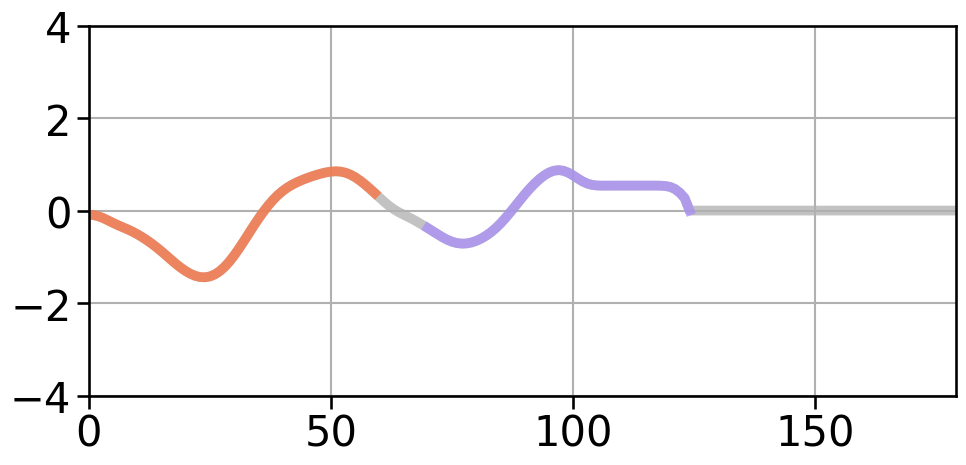

  Saved: plots/CharacterTrajectories/sample12_ch1.png


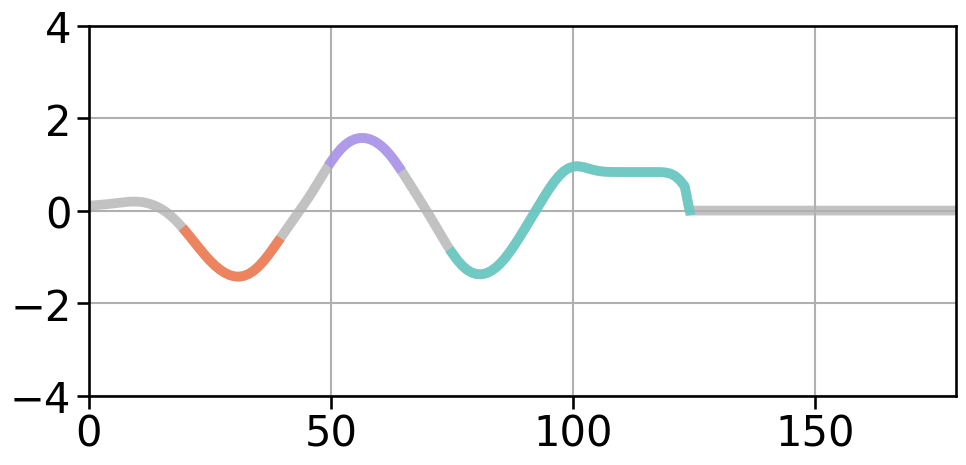

  Saved: plots/CharacterTrajectories/sample12_ch2.png


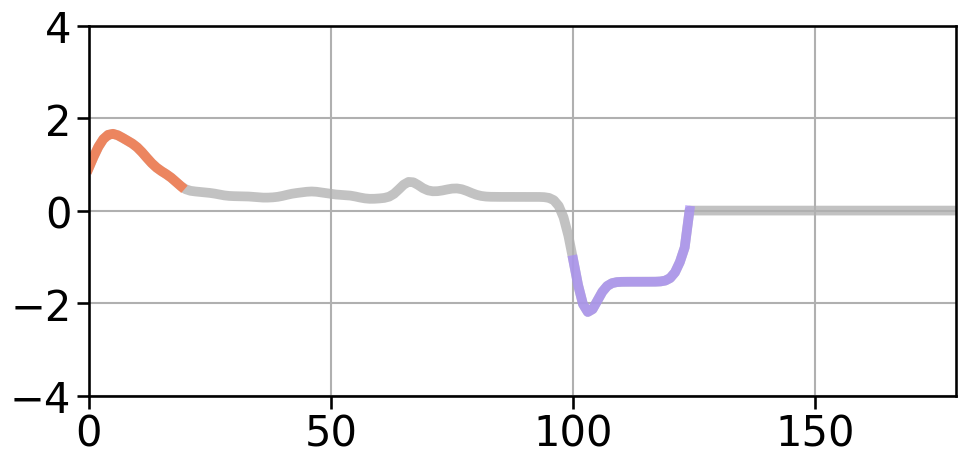

✅ Sample 12: 3 channel plots saved
  Saved: plots/CharacterTrajectories/sample14_ch0.png


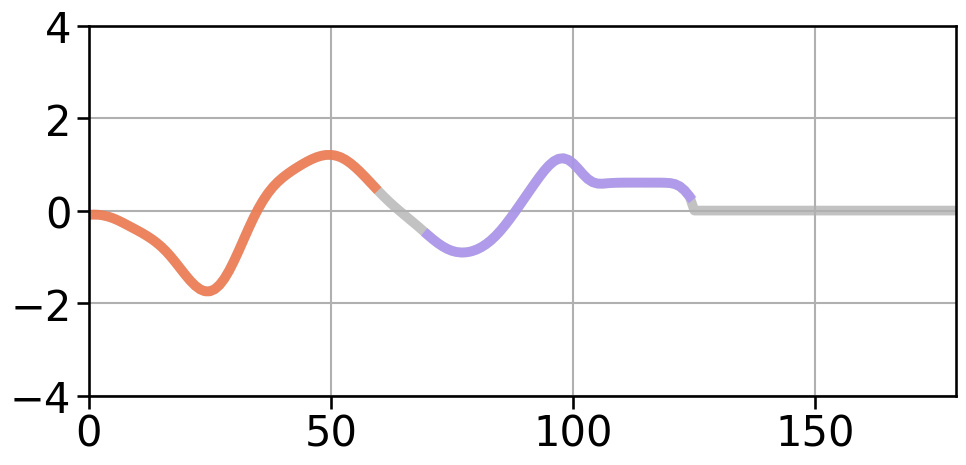

  Saved: plots/CharacterTrajectories/sample14_ch1.png


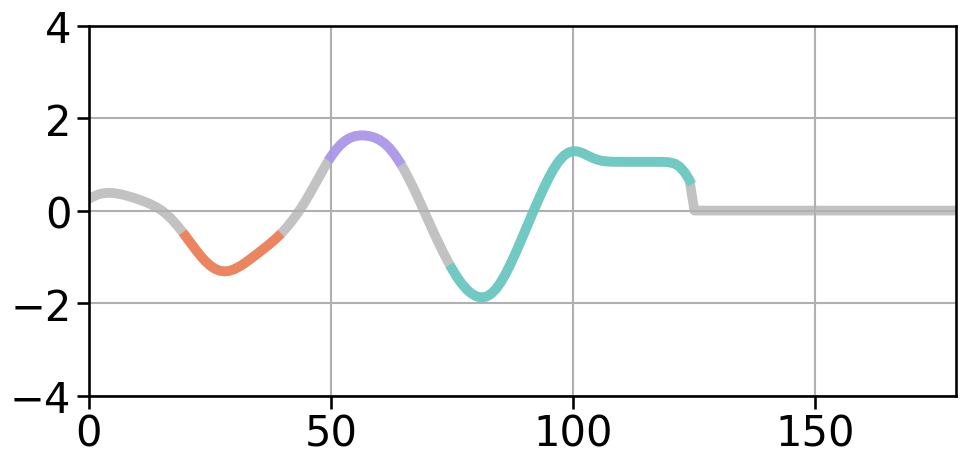

  Saved: plots/CharacterTrajectories/sample14_ch2.png


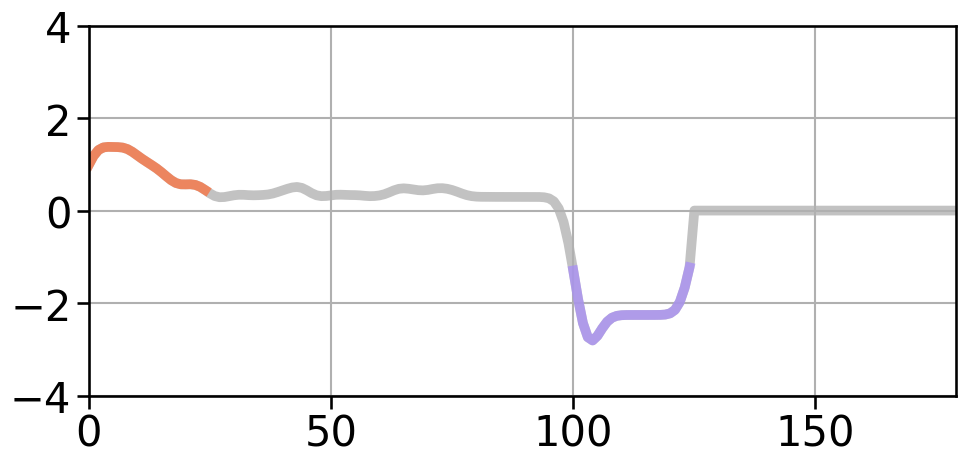

✅ Sample 14: 3 channel plots saved

📁 All plots saved to: plots/CharacterTrajectories


In [ ]:
# ============== Channel-wise Plotting with PNG Save ==============
import os

# Style settings
sns.set_context("talk")
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 30
mpl.rcParams["ytick.labelsize"] = 30

# Save directory
save_dir = f"plots/{dataset_name}"
os.makedirs(save_dir, exist_ok=True)

# Color palette for Top-k shapelets
shapelet_colors = ["#FF6B35", "#A78BFA", "#4ECDC4"]  # Top-1, 2, 3

show_legend = False

for real_idx in target_indices:
    if real_idx not in found_samples:
        print(f"Sample {real_idx} not found.")
        continue
    
    sample_info = found_samples[real_idx]
    orig = sample_info['original']
    z_tilde = sample_info['z_tilde']
    locations = sample_info['locations']  # (m, start, end)
    label = sample_info['label']
    pred = sample_info['pred']
    
    n_channels = orig.shape[0]
    
    for ch in range(n_channels):
        # Create figure for this channel
        fig, axes = plt.subplots(1, 1, figsize=(10, 5), squeeze=False)
        ax = axes[0, 0]
        
        orig_ch = orig[ch].numpy()
        z_ch = z_tilde[ch].numpy()
        x_len = len(orig_ch)
        
        # Original data
        ax.plot(range(x_len), orig_ch, 
                color="0.75", linewidth=7.0, alpha=0.95, 
                label="Original", zorder=1)
        
        # ROI regions for this channel
        region_count = 0
        for (m, start, end) in locations:
            if m != ch:
                continue
            safe_start = max(0, start)
            safe_end = min(end, x_len)
            if safe_start >= safe_end:
                continue
            
            # Get color from palette (cycle if more than 3)
            color = shapelet_colors[region_count % len(shapelet_colors)]
            
            ax.plot(range(safe_start, safe_end), z_ch[safe_start:safe_end],
                    color=color, linewidth=7.0, alpha=0.7,
                    label=f"Region #{region_count+1} ({safe_start}-{safe_end})",
                    zorder=2 + region_count)
            region_count += 1
        
        # Axis settings
        ax.set_xlim(0, x_len - 1)
        ax.set_ylim(-4, 4)
        ax.grid(True)
        
        # Legend
        if show_legend:
            ax.legend(loc='upper right', fontsize=9, frameon=False, handlelength=2)
        
        # # Title
        # title = f"{dataset_name} - Sample {real_idx}, Ch {ch}"
        # if label is not None:
        #     title += f" (Label: {label}, Pred: {pred})"
        # ax.set_title(title)
        
        plt.tight_layout()
        
        # # Save PNG
        # png_path = os.path.join(save_dir, f"sample{real_idx}_ch{ch}.png")
        # fig.savefig(png_path, dpi=150, bbox_inches='tight')
        # print(f"  Saved: {png_path}")
        
        plt.show()
        plt.close(fig)
    
    print(f"✅ Sample {real_idx}: {n_channels} channel plots saved")

## Plot All Channels (Optional)

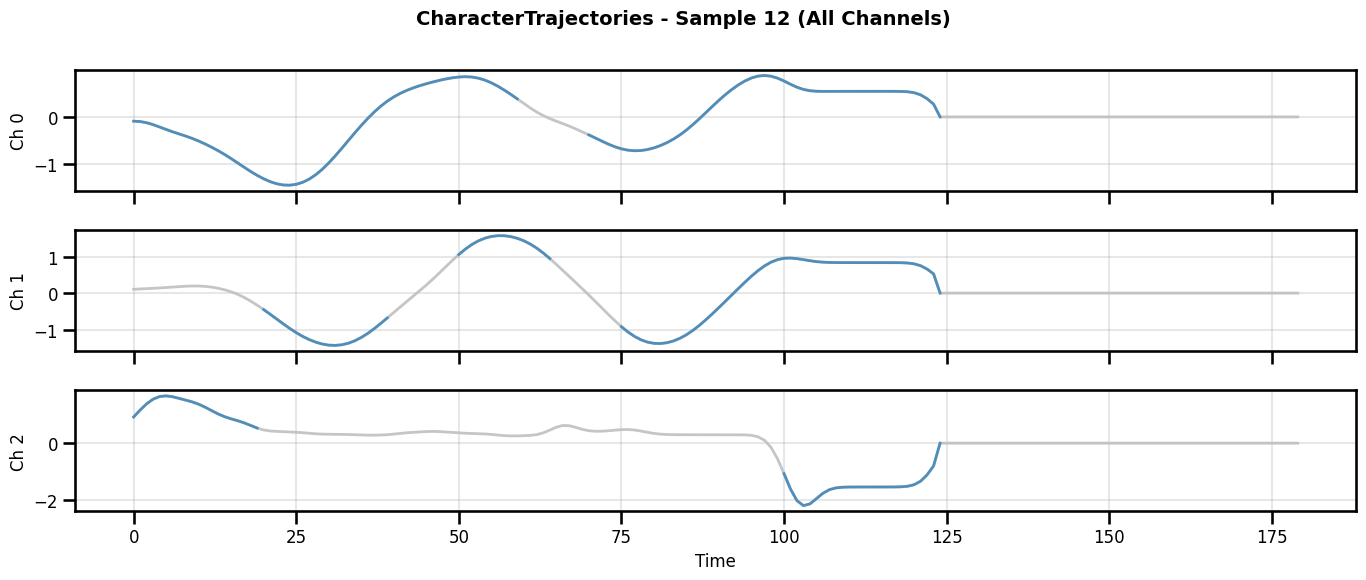

In [36]:
# Plot all channels for a single sample
sample_idx = target_indices[0]

if sample_idx in found_samples:
    sample_info = found_samples[sample_idx]
    orig = sample_info['original']
    z_tilde = sample_info['z_tilde']
    
    n_channels = orig.shape[0]
    fig, axes = plt.subplots(n_channels, 1, figsize=(14, 2*n_channels), sharex=True)
    
    if n_channels == 1:
        axes = [axes]
    
    for ch in range(n_channels):
        ax = axes[ch]
        orig_ch = orig[ch].numpy()
        z_ch = z_tilde[ch].numpy()
        x_len = len(orig_ch)
        
        # Original
        ax.plot(range(x_len), orig_ch, color="0.75", linewidth=2.0, alpha=0.9)
        
        # Find ROI regions for this channel
        mask = np.abs(z_ch) > 1e-8
        diff = np.diff(mask.astype(int), prepend=0, append=0)
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]
        
        for s, e in zip(starts, ends):
            if e > s:
                ax.plot(range(s, e), z_ch[s:e], color="#1F77B4", linewidth=2.0, alpha=0.7)
        
        ax.set_ylabel(f"Ch {ch}")
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel("Time")
    fig.suptitle(f"{dataset_name} - Sample {sample_idx} (All Channels)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [32]:
# ============== Load Global Shapelets ==============

shapelet_dir = os.path.join(shapelet_root, dataset_name)
shapelet_files = glob.glob(os.path.join(shapelet_dir, "global_shapelets_*.pt"))
if not shapelet_files:
    raise FileNotFoundError(f"No shapelet files found in {shapelet_dir}")
shapelet_path = max(shapelet_files, key=os.path.getmtime)

cluster_centers, channel_labels, params = load_cluster_centers_uea(shapelet_path)
print(f"✅ Loaded {len(cluster_centers)} shapelets from {os.path.basename(shapelet_path)}")
print(f"   channel_labels: {channel_labels}")

✅ Loaded 25 shapelets from global_shapelets_25c_20260119_204406.pt
   channel_labels: [1, 0, 0, 1, 1, 2, 2, 1, 0, 2, 1, 0, 0, 2, 1, 0, 0, 2, 1, 1, 0, 1, 1, 2, 1]


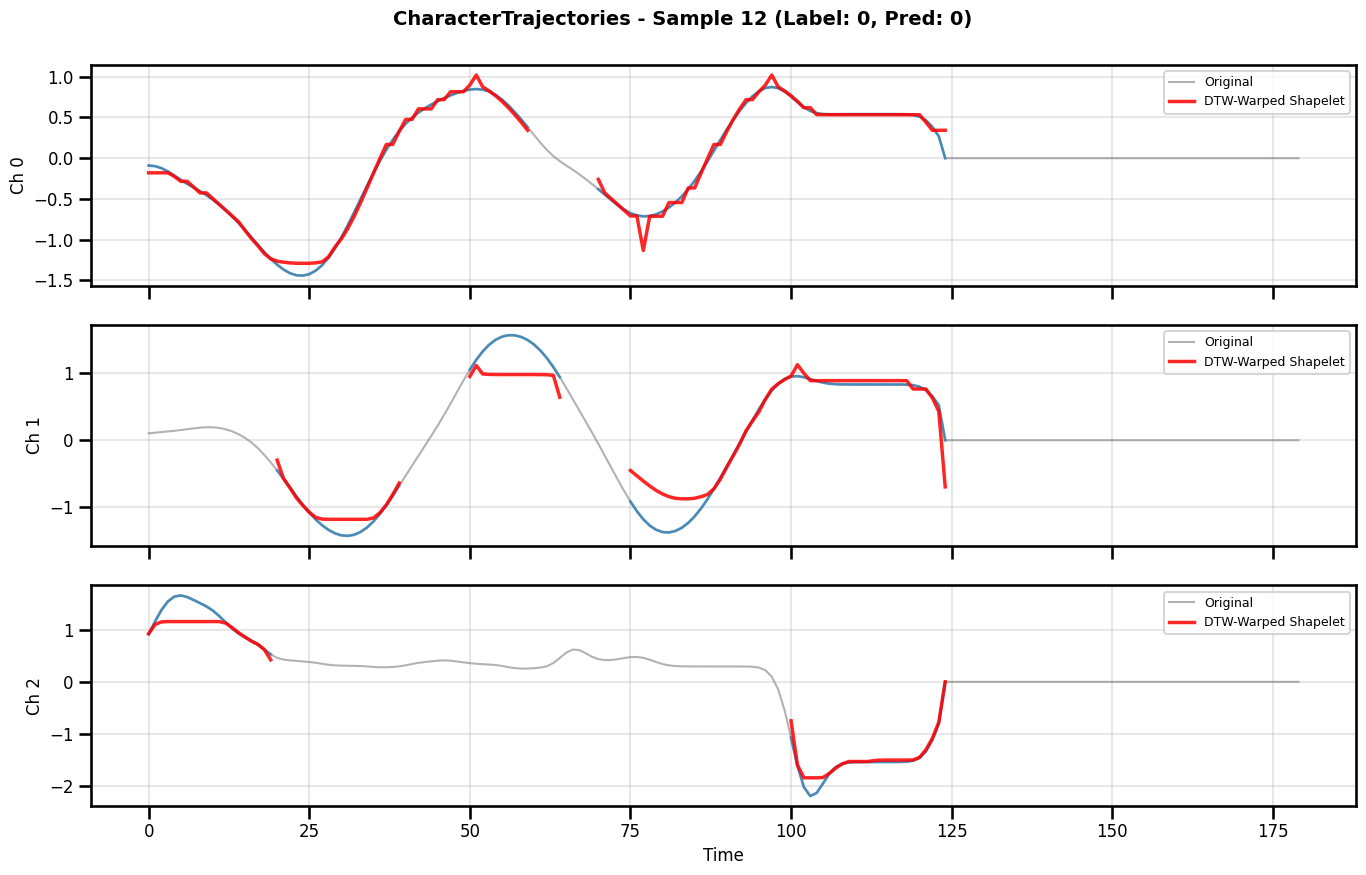

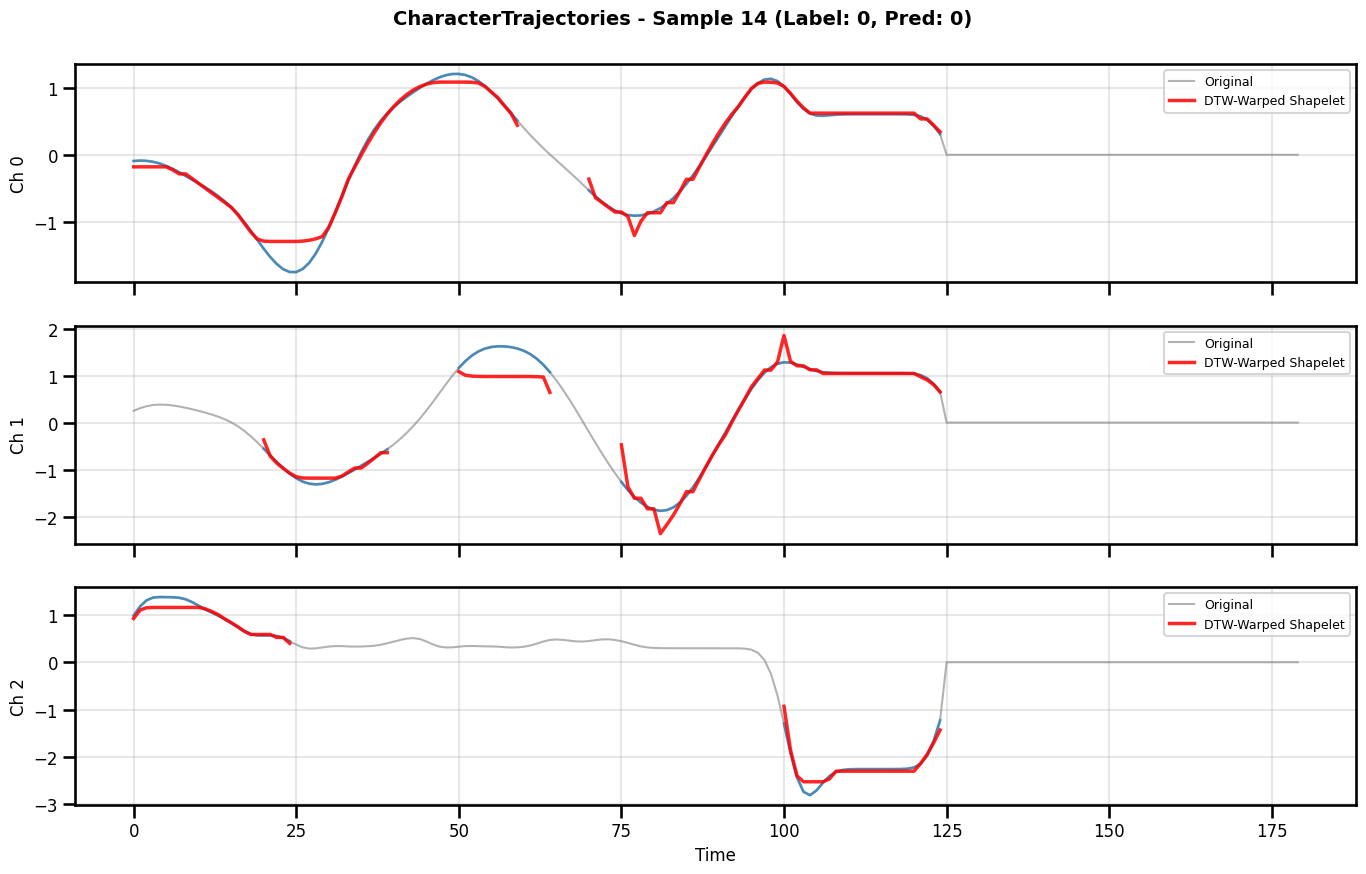

✅ Saved 2 samples to saved_results/replaced_CharacterTrajectories_dtw.pt


In [33]:
# ============== Run ==============
plot_replaced_shapelet_uea(model, test_loader, cluster_centers, channel_labels, target_indices=target_indices)

save_selected_samples_with_replacement_uea(
    model, test_loader, cluster_centers, channel_labels,
    target_indices=target_indices, save_filename=f"replaced_{dataset_name}_dtw.pt"
)

In [ ]:
# ============== Save Instance-to-Population Data ==============
def save_instance_to_population_data(
    model, test_loader, cluster_centers, channel_labels,
    target_indices=None, save_dir="saved_results",
    save_filename="instance_to_population.pt"
):
    """
    Save data for Instance-to-Population visualization.
    
    Output structure:
    {
        sample_idx: {
            'original': tensor [C, T],
            'label': int,
            'pred': int,
            'regions': {
                'ch0_10-50': {
                    'channel': 0,
                    'start': 10,
                    'end': 50,
                    'roi_segment': tensor,       
                    'global_shapelet_id': int,   
                    'warped_shapelet': tensor  
                },
                ...
            }
        },
        ...
    }
    """
    model.eval()
    os.makedirs(save_dir, exist_ok=True)
    
    target_set = set(target_indices) if target_indices else set(range(4))
    result = {}
    global_idx = 0
    
    with torch.no_grad():
        for batch in test_loader:
            data, target = (batch[0], batch[1] if len(batch) > 1 else None) \
                           if isinstance(batch, (list, tuple)) else (batch, None)
            
            # UEA: [B, T, D] -> [B, D, T]
            if data.dim() == 3 and data.shape[1] > data.shape[2]:
                data = data.transpose(1, 2)
            
            B = data.shape[0]
            batch_start_idx = global_idx
            batch_indices = [b for b in range(B) if (batch_start_idx + b) in target_set]
            
            if batch_indices:
                outputs = model(data.to(device), training=False, tau=1.3)
                z_tilde, pred_batch = outputs[2], outputs[0]
                candidates, locations = extract_shapelet_candidates_from_union(z_tilde)
                
                for b in batch_indices:
                    sample_idx = batch_start_idx + b
                    orig_sample = data[b].detach().cpu()
                    z_tilde_sample = z_tilde[b].detach().cpu()
                    
                    regions_dict = {}
                    
                    # Process each ROI region
                    for i, (bb, mm, start, end) in enumerate(locations):
                        if bb != b:
                            continue
                        
                        # Region key: "ch{channel}_{start}-{end}"
                        region_key = f"ch{mm}_{start}-{end}"
                        
                        # Extract ROI segment
                        roi_segment = z_tilde_sample[mm, start:end]
                        
                        # Match to global shapelet
                        shapelet = candidates[i]
                        center_idx, dist = match_shapelet_by_channel(
                            shapelet, cluster_centers, channel_labels, mm
                        )
                        
                        if center_idx != -1:
                            # Warp global shapelet to match region length
                            warped = apply_dtw_warping(shapelet, cluster_centers[center_idx])
                            
                            regions_dict[region_key] = {
                                'channel': mm,
                                'start': start,
                                'end': end,
                                'roi_segment': roi_segment,
                                'global_shapelet_id': center_idx,
                                'warped_shapelet': warped,
                                'dtw_distance': dist
                            }
                    
                    result[sample_idx] = {
                        'original': orig_sample,
                        'label': target[b].item() if target is not None else -1,
                        'pred': pred_batch[b].argmax().item(),
                        'regions': regions_dict
                    }
            
            global_idx += B
            if len(result) >= len(target_set):
                break
    
    # Save
    save_path = os.path.join(save_dir, save_filename)
    save_data = {
        'dataset': dataset_name,
        'n_samples': len(result),
        'n_global_shapelets': len(cluster_centers),
        'samples': result
    }
    torch.save(save_data, save_path)
    
    print(f"✅ Saved Instance-to-Population data to {save_path}")
    print(f"   Samples: {len(result)}")
    for idx, info in result.items():
        print(f"   Sample {idx}: {len(info['regions'])} regions")
    
    return save_path, result

In [35]:
# Run
save_path, data = save_instance_to_population_data(
    model, test_loader, cluster_centers, channel_labels,
    target_indices=target_indices,
    save_filename=f"instance_to_population_{dataset_name}.pt"
)

# 결과 확인
for sample_idx, sample_data in data.items():
    print(f"\n=== Sample {sample_idx} (Label: {sample_data['label']}) ===")
    print(f"Original shape: {sample_data['original'].shape}")
    for region_key, region_info in sample_data['regions'].items():
        print(f"  {region_key}: shapelet_id={region_info['global_shapelet_id']}, "
              f"warped_len={len(region_info['warped_shapelet'])}")

✅ Saved Instance-to-Population data to saved_results/instance_to_population_CharacterTrajectories.pt
   Samples: 2
   Sample 12: 7 regions
   Sample 14: 7 regions

=== Sample 12 (Label: 0) ===
Original shape: torch.Size([3, 180])
  ch0_0-60: shapelet_id=2, warped_len=60
  ch0_70-125: shapelet_id=2, warped_len=55
  ch1_20-40: shapelet_id=0, warped_len=20
  ch1_50-65: shapelet_id=24, warped_len=15
  ch1_75-125: shapelet_id=3, warped_len=50
  ch2_0-20: shapelet_id=6, warped_len=20
  ch2_100-125: shapelet_id=13, warped_len=25

=== Sample 14 (Label: 0) ===
Original shape: torch.Size([3, 180])
  ch0_0-60: shapelet_id=2, warped_len=60
  ch0_70-125: shapelet_id=2, warped_len=55
  ch1_20-40: shapelet_id=0, warped_len=20
  ch1_50-65: shapelet_id=24, warped_len=15
  ch1_75-125: shapelet_id=14, warped_len=50
  ch2_0-25: shapelet_id=6, warped_len=25
  ch2_100-125: shapelet_id=9, warped_len=25
